In [29]:
import torch 
import torch.nn as nn

class GMSKAutoEncoder(nn.Module):
    def __init__(self):
        super(GMSKAutoEncoder, self).__init__()

        # Encoder : Compresses noisy I & Q stream into features
        self.encoder = nn.Sequential(
            # Input shape: (batch_size, 2, signal_length)
            nn.Conv1d(2, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        # Decoder : Reconstructs clean I & Q stream from features
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 16, kernel_size=2, stride=2),
            nn.BatchNorm1d(16),
            nn.Tanh(),
            nn.Conv1d(16, 8, kernel_size=3, padding=1),
            nn.BatchNorm1d(8),
            nn.Tanh(),
            nn.Conv1d(8, 2, kernel_size=3, padding=1), # Output shape: (batch_size, 2, signal_length)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    
    def summary(self, input_size = (2, 2048)):
        from torchsummary import summary
        summary(self, input_size=input_size)  

In [30]:
import torch.optim as optim
from pathlib import Path
import numpy as np

data_path = Path.cwd().parent / "Data"

# Load Data
X = torch.from_numpy(np.load(data_path / "X_noisy.npy")).float()  # Noisy signals
Y = torch.from_numpy(np.load(data_path / "Y_clean.npy")).float()  # Clean signals

In [31]:
# Setup model, loss & optimizer
model = GMSKAutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50

model.summary()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1             [-1, 16, 2048]             112
       BatchNorm1d-2             [-1, 16, 2048]              32
              ReLU-3             [-1, 16, 2048]               0
            Conv1d-4             [-1, 32, 2048]           1,568
       BatchNorm1d-5             [-1, 32, 2048]              64
              ReLU-6             [-1, 32, 2048]               0
         MaxPool1d-7             [-1, 32, 1024]               0
   ConvTranspose1d-8             [-1, 16, 2048]           1,040
       BatchNorm1d-9             [-1, 16, 2048]              32
             Tanh-10             [-1, 16, 2048]               0
           Conv1d-11              [-1, 8, 2048]             392
      BatchNorm1d-12              [-1, 8, 2048]              16
             Tanh-13              [-1, 8, 2048]               0
           Conv1d-14              [-1, 

In [32]:
# Define the path
save_path = Path.cwd().parent / "weights" / "gmsk_denoiser.pth"

# Ensure the 'weights' directory exists
save_path.parent.mkdir(parents=True, exist_ok=True)

# --- The "Train Once" Logic ---
if save_path.exists():
    print(f"--- Loading weights from {save_path} ---")
    # Load the state dictionary into the model
    model.load_state_dict(torch.load(save_path, weights_only=True))
    model.eval() # Set to evaluation mode
else:
    print("--- Weight file not found. Starting Training... ---")
    model.train() # Ensure model is in training mode
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        optimizer.step()
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")

    # Save after the first training
    torch.save(model.state_dict(), save_path)
    print(f"--- Training complete. Model saved to {save_path} ---")

--- Weight file not found. Starting Training... ---
Epoch 0, Loss: 0.7239068746566772
Epoch 10, Loss: 0.4266294538974762
Epoch 20, Loss: 0.34729328751564026
Epoch 30, Loss: 0.277619868516922
Epoch 40, Loss: 0.2443629801273346
--- Training complete. Model saved to c:\Users\charl\OneDrive\Bureau\Cubesat-Radioastronomie\weights\gmsk_denoiser.pth ---


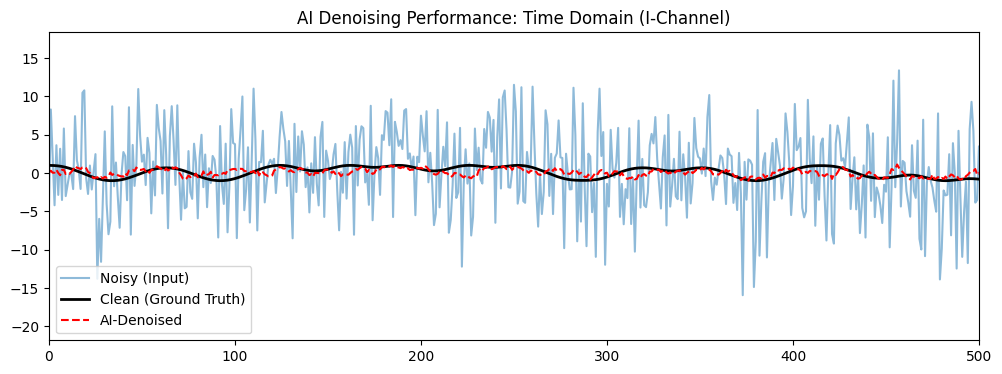

In [33]:
import matplotlib.pyplot as plt

# 1. Select a high-noise sample (e.g., SNR = 0dB)
sample_idx = 0 
noisy_input = X[sample_idx:sample_idx+1] # Shape: (1, 2, Length)

# 2. Run through the AI
model.eval()
with torch.no_grad():
    denoised_output = model(noisy_input).squeeze(0).numpy()

# 3. Plot I-channel comparison
plt.figure(figsize=(12, 4))
plt.plot(noisy_input[0, 0, :].numpy(), label='Noisy (Input)', alpha=0.5)
plt.plot(Y[sample_idx, 0, :].numpy(), label='Clean (Ground Truth)', color='black', lw=2)
plt.plot(denoised_output[0, :], label='AI-Denoised', color='red', linestyle='--')
plt.xlim(0, 500)
plt.title("AI Denoising Performance: Time Domain (I-Channel)")
plt.legend()
plt.show()

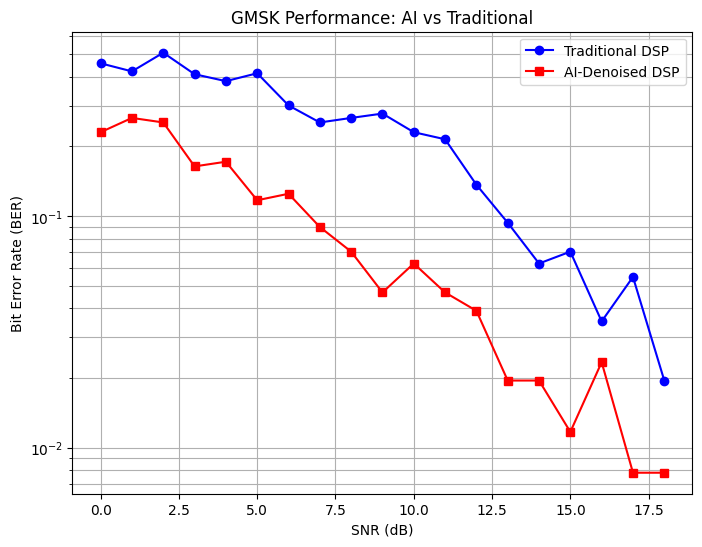

In [34]:
from src.demodulation import gmsk_demod
from src.test_gen import generate_test_signal
snr_range = np.arange(0, 19)  # SNRs from 0dB to 19dB
L = 8  # Samples per symbol
fc = 146e6  # Carrier frequency

ber_traditional = []
ber_ai_assisted = []

model.eval()

for snr in snr_range:
    # 1. Generate test data for this specific SNR
    # (Assuming you have a helper to generate bits and noisy signals)
    bits, s_noisy, s_clean = generate_test_signal(snr, L, fc)
    
    # --- Traditional Path ---
    bits_trad = gmsk_demod(s_noisy, L)
    err_trad = np.sum(bits != bits_trad) / len(bits)
    ber_traditional.append(err_trad)
    
    # --- AI Path ---
    # Prepare for model: (1, 2, Length)
    input_tensor = torch.from_numpy(np.vstack((s_noisy.real, s_noisy.imag))).float().unsqueeze(0)
    with torch.no_grad():
        denoised_iq_raw = model(input_tensor).squeeze(0).numpy()
    
    # Reconstruct complex signal from AI output
    s_denoised = denoised_iq_raw[0, :] + 1j * denoised_iq_raw[1, :]
    
    bits_ai = gmsk_demod(s_denoised, L)
    err_ai = np.sum(bits != bits_ai) / len(bits)
    ber_ai_assisted.append(err_ai)

# Plotting the Waterfall Curve
plt.figure(figsize=(8, 6))
plt.semilogy(snr_range, ber_traditional, 'b-o', label='Traditional DSP')
plt.semilogy(snr_range, ber_ai_assisted, 'r-s', label='AI-Denoised DSP')
plt.grid(True, which='both')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('GMSK Performance: AI vs Traditional')
plt.legend()
plt.show()

In [35]:
bits, s_noisy, s_clean = generate_test_signal(10, L, fc)

input_tensor = torch.from_numpy(np.vstack((s_noisy.real, s_noisy.imag))).float().unsqueeze(0)
with torch.no_grad():
    denoised_iq_raw = model(input_tensor).squeeze(0).numpy()

denoised_iq = denoised_iq_raw[0, :] + 1j * denoised_iq_raw[1, :]


C:\Users\charl\OneDrive\Bureau\Cubesat-Radioastronomie\src\spectra.py:62: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Sxx = spectrogram(x, fs, nperseg=1024, noverlap=512)


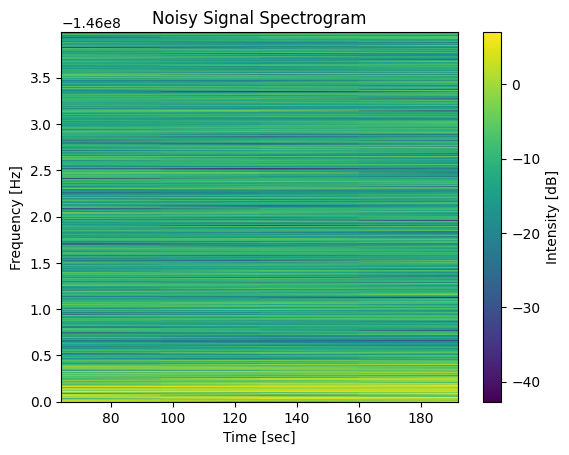

In [36]:
# Plot spectrogram for noisy signal
from src.spectra import plot_spectrogram

plot_spectrogram(s_noisy, L, fc, title="Noisy Signal Spectrogram")

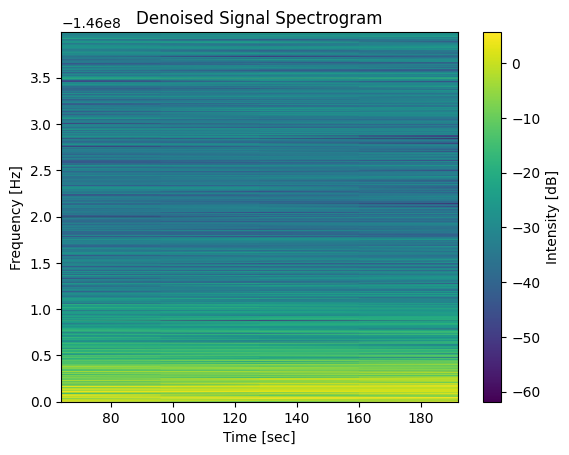

In [37]:
# Plot spectrogram for denoised signal
plot_spectrogram(denoised_iq, L, fc, title="Denoised Signal Spectrogram")

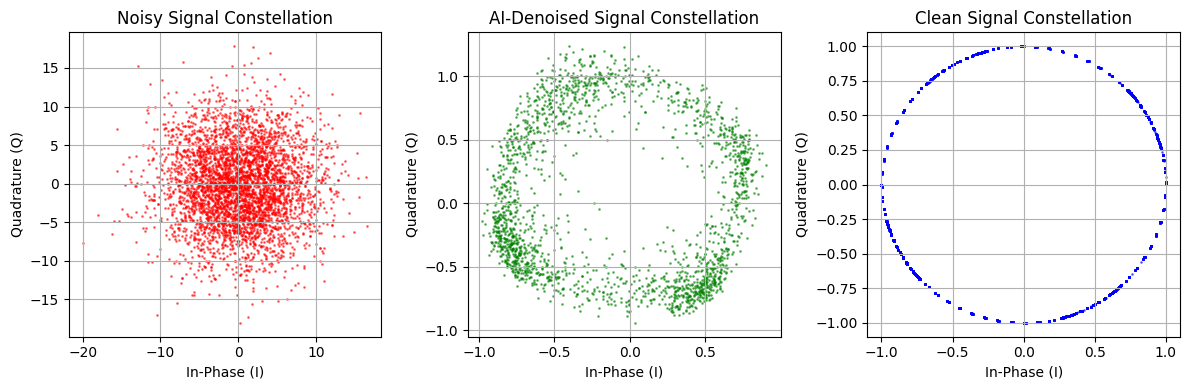

In [38]:
i_noisy = noisy_input[sample_idx, 0, :].numpy()
q_noisy = noisy_input[sample_idx, 1, :].numpy()

i_clean = Y[sample_idx, 0, :].numpy()
q_clean = Y[sample_idx, 1, :].numpy()

i_denoised = denoised_iq_raw[0, :]
q_denoised = denoised_iq_raw[1, :]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.scatter(i_noisy, q_noisy, s=1, alpha=0.5, color = 'r')
ax1.set_title('Noisy Signal Constellation')
ax1.set_xlabel('In-Phase (I)')
ax1.set_ylabel('Quadrature (Q)')
ax1.grid(True)

ax2.scatter(i_denoised, q_denoised, s=1, alpha=0.5, color = 'g')
ax2.set_title('AI-Denoised Signal Constellation')
ax2.set_xlabel('In-Phase (I)')
ax2.set_ylabel('Quadrature (Q)')
ax2.grid(True)

ax3.scatter(i_clean, q_clean, s=1, alpha=0.5, color = 'b')
ax3.set_title('Clean Signal Constellation')
ax3.set_xlabel('In-Phase (I)')
ax3.set_ylabel('Quadrature (Q)')
ax3.grid(True)

plt.tight_layout()
plt.show()